# Практична робота 1

## Формулювання задачі, аудит, аналіз ознак, візуалізація розподілів, викиди та взаємозв'язки

**Набір даних:** Iris (Ірис) — індивідуальний варіант, **цільова ознака: `sepal width` (ширина чашолистка)**

**Дисципліна:** Машинне навчання

**Виконав(ла):** Воловник Я

**Група:** ІПЗ-23

---

> **Важливо.** Метою цієї практичної роботи є **розуміння та підготовка даних**, а не побудова моделі. Модель у цій роботі не будується.

## 1. Формулювання задачі та опис індивідуального набору даних

### 1.1. Назва та джерело набору даних

Використовується класичний набір даних **Iris (Ірис Фішера)**, зібраний Р. Фішером у 1936 р. У цій роботі він завантажується через вбудований завантажувач `sklearn.datasets.load_iris`, який містить точну копію оригінального набору (UCI Machine Learning Repository, "Iris Data Set", https://archive.ics.uci.edu/dataset/53/iris).

### 1.2. Предметна область

Предметна область — **ботаніка / морфометрія рослин**. Набір містить результати вимірювання квіток трьох видів ірису (*Iris setosa*, *Iris versicolor*, *Iris virginica*): довжину та ширину чашолистків (sepal) і пелюсток (petal).

### 1.3. Об'єкти, що описуються рядками таблиці

Кожен рядок таблиці відповідає **одній окремій квітці ірису** (одному ботанічному зразку), для якої виміряно чотири морфометричні ознаки та визначено вид рослини.

### 1.4–1.7. Кількість об'єктів і ознак, цільова змінна, тип задачі, практичний зміст

- **Цільова змінна (за умовою індивідуального варіанта):** `sepal_width` (ширина чашолистка, см) — неперервна кількісна ознака.
- **Тип майбутньої задачі машинного навчання:** **регресія**, а не класифікація, як у класичному використанні цього набору даних.
- **Ознаки-предиктори:** `sepal_length`, `petal_length`, `petal_width`, а також категоріальна ознака `species`.
- **Практичний зміст майбутнього прогнозування:** пряме вимірювання ширини чашолистка іноді ускладнене; модель, що прогнозує `sepal_width` за іншими ознаками, дозволила б оцінювати цю характеристику непрямим шляхом.

Кількість об'єктів і ознак наводиться нижче за фактичним результатом `df.shape` (розділ 2).

## 2. Первинний аудит даних

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris

pd.set_option('display.max_columns', None)

# Завантаження даних
iris = load_iris(as_frame=True)
df = iris.frame.copy()
df.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'target']
species_map = dict(zip(range(3), iris.target_names))
df['species'] = df['target'].map(species_map)
df = df.drop(columns=['target'])

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
df.shape

(150, 5)

**Розмірність таблиці:** `(150, 5)` — **150 об'єктів**, **5 стовпців**: 4 числові ознаки + 1 категоріальна (`species`).

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [5]:
df.dtypes

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

In [6]:
df.nunique()

sepal_length    35
sepal_width     23
petal_length    43
petal_width     22
species          3
dtype: int64

In [7]:
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [8]:
missing_count = df.isnull().sum()
missing_share = (df.isnull().mean() * 100).round(2)
pd.DataFrame({'кількість_пропусків': missing_count, 'частка_пропусків_%': missing_share})

,кількість_пропусків,частка_пропусків_%
sepal_length,0,0.0
sepal_width,0,0.0
petal_length,0,0.0
petal_width,0,0.0
species,0,0.0


**Пропущені значення відсутні** — 0 у кожному стовпці (0.0%).

In [9]:
duplicate_count = df.duplicated().sum()
print('Кількість повних дублікатів рядків:', duplicate_count)
df[df.duplicated(keep=False)].sort_values(list(df.columns))

Кількість повних дублікатів рядків: 1


,sepal_length,sepal_width,petal_length,petal_width,species
101,5.8,2.7,5.1,1.9,virginica
142,5.8,2.7,5.1,1.9,virginica


Виявлено **1 повний дублікат** (рядки 101 і 142, обидва `virginica`). Службових/ID-стовпців у наборі немає.

## 3. Аналіз числових ознак

**Числові ознаки визначаються за їхнім змістом, а не лише за типом `pandas`.**

In [10]:
raw = load_iris(as_frame=True).frame
print(raw.dtypes)
print()
print("Унікальні значення стовпця 'target':", raw['target'].unique())

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
dtype: object

Унікальні значення стовпця 'target': [0 1 2]


У сирому наборі `target` має тип `int64`, але значення `0,1,2` — це **коди категорій**, а не кількісна величина. Тому справжні числові ознаки в нашому робочому наборі — рівно чотири: `sepal_length`, `sepal_width`, `petal_length`, `petal_width`.

In [11]:
num_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

stats = df[num_cols].agg(
    ['count', 'mean', 'std', 'min',
     lambda x: x.quantile(0.25), 'median',
     lambda x: x.quantile(0.75), 'max']
).T
stats.columns = ['count', 'mean', 'std', 'min', 'Q1', 'median', 'Q3', 'max']
stats['mean_minus_median'] = (stats['mean'] - stats['median']).round(3)
stats['range'] = stats['max'] - stats['min']
stats['IQR'] = stats['Q3'] - stats['Q1']
stats['CV_%'] = (stats['std'] / stats['mean'] * 100).round(1)
stats.round(3)

,count,mean,std,min,Q1,median,Q3,max,mean_minus_median,range,IQR,CV_%
sepal_length,150.0,5.843,0.828,4.3,5.1,5.80,6.4,7.9,0.043,3.6,1.3,14.2
sepal_width,150.0,3.057,0.436,2.0,2.8,3.00,3.3,4.4,0.057,2.4,0.5,14.3
petal_length,150.0,3.758,1.765,1.0,1.6,4.35,5.1,6.9,-0.592,5.9,3.5,47.0
petal_width,150.0,1.199,0.762,0.1,0.3,1.30,1.8,2.5,-0.101,2.4,1.5,63.6


In [12]:
df[num_cols].skew().rename('асиметрія (skew)').to_frame()

,асиметрія (skew)
sepal_length,0.314911
sepal_width,0.318966
petal_length,-0.274884
petal_width,-0.102967


**Середнє vs медіана:** `sepal_*` — легка правостороння асиметрія (+0.32). `petal_length` — найбільша різниця (mean−median = −0.592), спричинена сумішшю трьох видових підгруп, а не класичною асиметрією.

**Діапазон:** найбільший у `petal_length` (5.9 см).

**Дуже великий розкид (CV = std/mean):** `petal_width` (63.6%) і `petal_length` (47.0%) — у 3–4 рази більший за `sepal_*` (~14%), через сильні міжвидові відмінності розмірів пелюстки.

**Підозрілі мін./макс.:** перевірено нижче разом із boxplot-аналізом у розділі 6.

## 4. Аналіз категоріальних ознак

Категоріальні ознаки також визначаються **за змістом**: навіть закодований числом вид рослини (0/1/2) залишався б категорією. У наборі — одна така ознака, `species`.

In [13]:
print("Кількість унікальних категорій:", df['species'].nunique())
print()
print("Частоти:\n", df['species'].value_counts())
print()
print("Частки, %:\n", (df['species'].value_counts(normalize=True) * 100).round(2))
print()
print("Пропущені значення:", df['species'].isnull().sum())
print()
print("nunique 'як є':", df['species'].nunique(),
      "| nunique після lower+strip:", df['species'].str.strip().str.lower().nunique())

Кількість унікальних категорій: 3

Частоти:
 species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Частки, %:
 species
setosa        33.33
versicolor    33.33
virginica     33.33
Name: proportion, dtype: float64

Пропущені значення: 0

nunique 'як є': 3 | nunique після lower+strip: 3


**Підсумок:** 3 збалансовані категорії (по 50, 33.3% кожна), рідкісних категорій немає, пропусків немає, варіантів написання не виявлено, природного порядку немає (номінальна ознака), кардинальність дуже низька. **Висновок:** `species` доцільно використовувати як предиктор із **one-hot encoding** (не нумерацією 0/1/2, оскільки порядку між видами немає).

## 5. Візуальний аналіз розподілів

Немає потреби будувати однаковий набір графіків для кожного стовпця — нижче обрано ті візуалізації, які відповідають на конкретні питання: симетричність, асиметрія, довгі хвости, кілька локальних максимумів, окремі групи значень, потенційні аномалії.

In [14]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.0)
palette = {'setosa': '#4C72B0', 'versicolor': '#DD8452', 'virginica': '#55A868'}

### 5.1. `sepal_length` і `sepal_width` (цільова) — перевірка симетричності

Обидві ознаки мають близьку до нормальної форму (за розділом 3, асиметрія ≈ +0.32), тому доцільно перевірити це візуально одним поєднаним графіком, а не окремо для кожної.

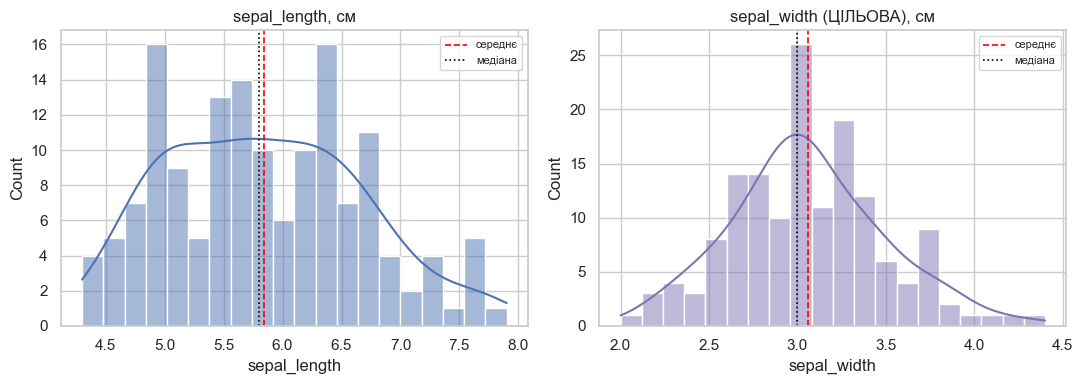

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df['sepal_length'], bins=20, kde=True, ax=axes[0], color='#4C72B0')
axes[0].axvline(df['sepal_length'].mean(), color='red', ls='--', lw=1.2, label='середнє')
axes[0].axvline(df['sepal_length'].median(), color='black', ls=':', lw=1.2, label='медіана')
axes[0].set_title('sepal_length, см')
axes[0].legend(fontsize=8)

sns.histplot(df['sepal_width'], bins=20, kde=True, ax=axes[1], color='#8172B2')
axes[1].axvline(df['sepal_width'].mean(), color='red', ls='--', lw=1.2, label='середнє')
axes[1].axvline(df['sepal_width'].median(), color='black', ls=':', lw=1.2, label='медіана')
axes[1].set_title('sepal_width (ЦІЛЬОВА), см')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig('01_hist_sepal_features.png', dpi=130, bbox_inches='tight')
plt.show()

**Висновок за графіком:**
- `sepal_width` (ціль) — розподіл близький до **симетричного, одномодальний**, з легким подовженням правого хвоста (кілька значень 4.0–4.4). Довгих хвостів немає, форма нагадує нормальний розподіл.
- `sepal_length` — переважно одномодальний, майже симетричний, але помітна **слабка "хвиля"**: невеликий провал близько 5.7–6.0 см і повторне зростання біля 6.2–6.5 см. Це натяк на змішування видових підгруп (менші квітки *setosa* проти більших *versicolor*/*virginica*), хоча тут групи перекриваються значно сильніше, ніж у пелюсткових ознаках (див. нижче), тому ефект слабкий і не утворює чітких окремих максимумів.
- Явних довгих хвостів чи аномалій на цих двох гістограмах не видно.

### 5.2. `petal_length` — чи є кілька локальних максимумів?

`petal_length` мала найбільшу різницю "середнє − медіана" (розділ 3) — перевіримо форму розподілу.

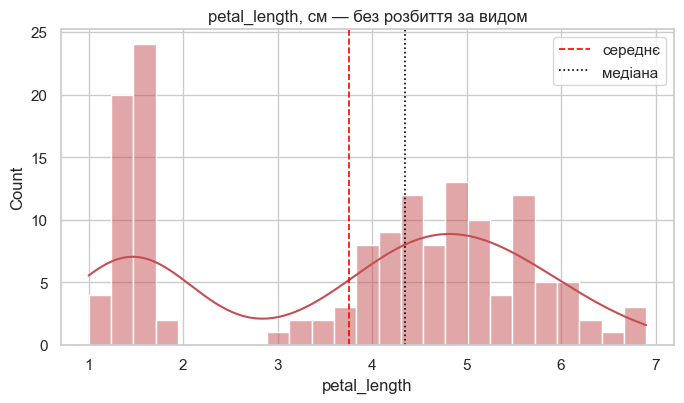

In [16]:
plt.figure(figsize=(7, 4.2))
sns.histplot(df['petal_length'], bins=25, kde=True, color='#C44E52')
plt.axvline(df['petal_length'].mean(), color='red', ls='--', lw=1.2, label='середнє')
plt.axvline(df['petal_length'].median(), color='black', ls=':', lw=1.2, label='медіана')
plt.title('petal_length, см — без розбиття за видом')
plt.legend()
plt.tight_layout()
plt.savefig('02_hist_petal_length_plain.png', dpi=130, bbox_inches='tight')
plt.show()

**Висновок за графіком:** розподіл явно **НЕ симетричний і НЕ одномодальний**: чітко видно ізольований "острівець" значень у діапазоні 1.0–1.9 см, провал (майже відсутність спостережень) близько 2.0–2.9 см, а потім ширший другий "горб" у діапазоні 3.0–6.9 см. Це класична ознака **суміші кількох підпопуляцій**, а не єдиного гладкого розподілу. Постає питання — чим викликана ця структура?

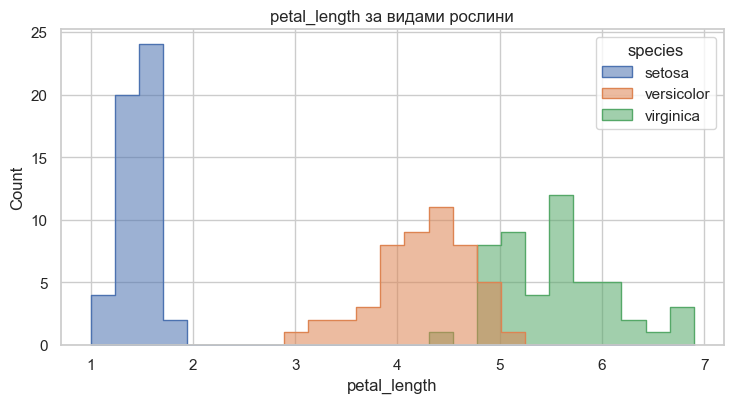

In [17]:
plt.figure(figsize=(7.5, 4.2))
sns.histplot(data=df, x='petal_length', hue='species', bins=25, palette=palette,
             element='step', multiple='layer', alpha=0.55)
plt.title('petal_length за видами рослини')
plt.tight_layout()
plt.savefig('03_hist_petal_length_by_species.png', dpi=130, bbox_inches='tight')
plt.show()

**Висновок за графіком:** розфарбування за видом повністю пояснює побачену бімодальність — **ізольована група зліва повністю відповідає *setosa*** (петлюстки стабільно короткі, 1.0–1.9 см, дуже вузький розкид), а ширший правий "горб" — це **накладені один на одного розподіли *versicolor* та *virginica***, які частково перекриваються в діапазоні ~4.5–5.1 см, але в цілому зсунуті одна відносно іншої (*versicolor* ліворуч, *virginica* праворуч). Отже, кілька локальних максимумів і окремі групи значень тут **не аномалія, а результат реальної біологічної відмінності між видами**.

### 5.3. `petal_width` — та ж перевірка на іншій ознаці

Оскільки логіка ідентична до `petal_length` (обидві — розміри пелюстки), тут достатньо **одного** графіка одразу з розфарбуванням за видом, без проміжного "простого" варіанта.

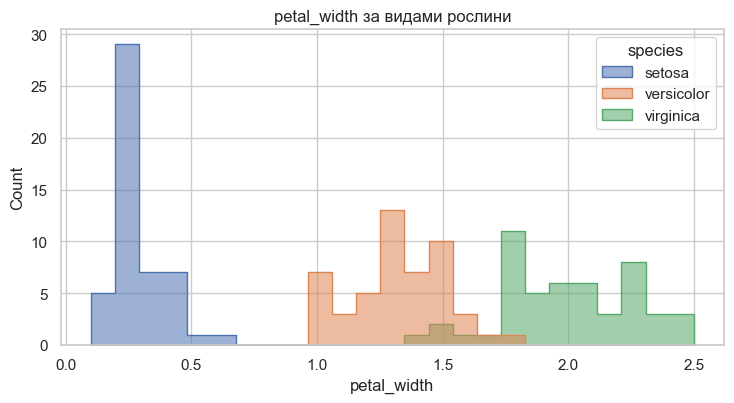

In [18]:
plt.figure(figsize=(7.5, 4.2))
sns.histplot(data=df, x='petal_width', hue='species', bins=25, palette=palette,
             element='step', multiple='layer', alpha=0.55)
plt.title('petal_width за видами рослини')
plt.tight_layout()
plt.savefig('04_hist_petal_width_by_species.png', dpi=130, bbox_inches='tight')
plt.show()

**Висновок за графіком:** розподіл `petal_width` розділений на групи ще чіткіше, ніж `petal_length`: *setosa* утворює вузьку, майже "стиснуту" групу біля нуля (0.1–0.6 см), тоді як *versicolor* (1.0–1.8 см) та *virginica* (1.4–2.5 см) розташовані значно вище, з помітним, хоч і неповним, перекриттям між собою. Явних довгих хвостів немає (значення обмежені фізично правдоподібним діапазоном), а "розрив" між *setosa* та рештою видів — не аномалія, а справжня біологічна межа.

### Підсумок розділу 5

| Ознака | Симетричність | Асиметрія | Довгі хвости | Кілька максимумів | Окремі групи | Аномалії |
|---|---|---|---|---|---|---|
| `sepal_length` | майже симетрична | дуже слабка | немає | натяк на слабку хвилю (не чіткий) | слабко виражені (сильне перекриття видів) | не виявлено |
| `sepal_width` | симетрична | дуже слабка (+0.32) | немає | одна (унімодальна) | не виражені | кілька крайніх точок (аналіз — розділ 6) |
| `petal_length` | **не симетрична** | сильна структурна | немає | **так, 2 виражені** | **так, за видом** | не виявлено (розкид — природний) |
| `petal_width` | **не симетрична** | сильна структурна | немає | **так, 2–3 виражені** | **так, за видом, ще чіткіше** | не виявлено |

## 6. Пошук аномалій та потенційних викидів

Використовуємо boxplot та правило IQR: `IQR = Q3 − Q1`, нижня межа `L = Q1 − 1.5·IQR`, верхня межа `U = Q3 + 1.5·IQR`. **Правило видалення викидів автоматично не застосовується** — кожен суттєвий випадок аналізується окремо.

### 6.1. Глобальні boxplot (без урахування виду рослини)

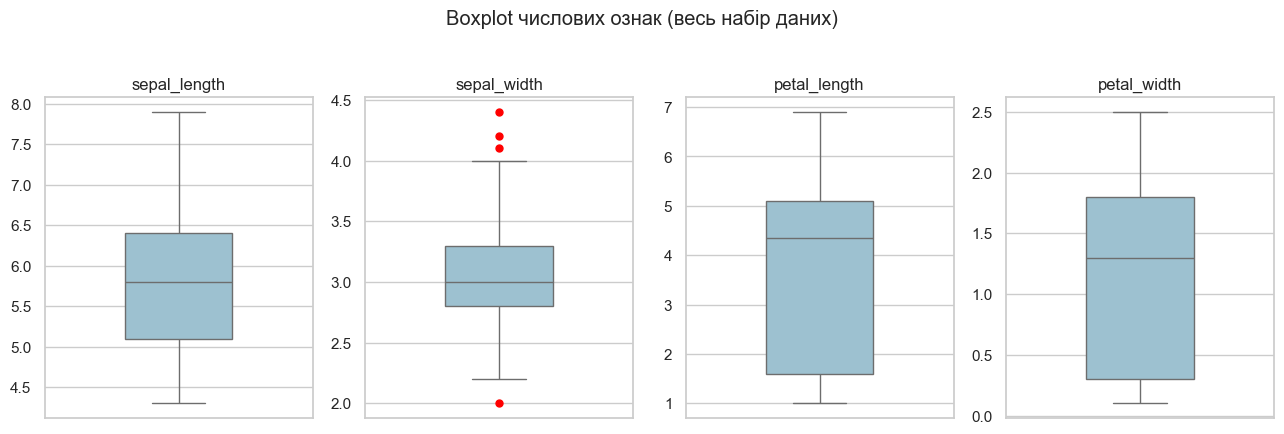

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(13, 4.2))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax, color='#94C4D8', width=0.4, fliersize=5,
                flierprops=dict(marker='o', markerfacecolor='red', markeredgecolor='red'))
    ax.set_title(col)
    ax.set_ylabel('')
plt.suptitle('Boxplot числових ознак (весь набір даних)', y=1.03)
plt.tight_layout()
plt.savefig('05_boxplots_all_features.png', dpi=130, bbox_inches='tight')
plt.show()

In [20]:
print("Кількість глобальних викидів за правилом 1.5*IQR:")
for c in num_cols:
    q1, q3 = df[c].quantile(0.25), df[c].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    out = df[(df[c] < lo) | (df[c] > hi)]
    print(f"{c}: межі=[{lo:.2f}, {hi:.2f}]  n_викидів={len(out)}")
    if len(out):
        print(out[[c, 'species']].to_string())

Кількість глобальних викидів за правилом 1.5*IQR:
sepal_length: межі=[3.15, 8.35]  n_викидів=0
sepal_width: межі=[2.05, 4.05]  n_викидів=4
    sepal_width     species
15          4.4      setosa
32          4.1      setosa
33          4.2      setosa
60          2.0  versicolor
petal_length: межі=[-3.65, 10.35]  n_викидів=0
petal_width: межі=[-1.95, 4.05]  n_викидів=0


**Висновок:** на глобальному рівні (без урахування виду) формальні викиди за правилом 1.5×IQR є **лише в `sepal_width`** — 4 точки: 4.4, 4.2, 4.1 (усі *setosa*) та 2.0 (*versicolor*, водночас мінімум усього набору). У решти трьох ознак викидів немає — саме тому, що їхній IQR штучно "розтягнутий" через змішування видів (розділ 3, 5), і формальні межі виявляються дуже широкими.

### 6.2. Boxplot з розбиттям за видом рослини

Глобальний IQR може **маскувати** справжні викиди всередині окремого виду і водночас **фальшиво позначати** як викид точку, яка насправді типова для свого виду, але нетипова для вибірки в цілому. Перевіримо це на прикладі цільової ознаки `sepal_width` та ознаки `petal_length`.

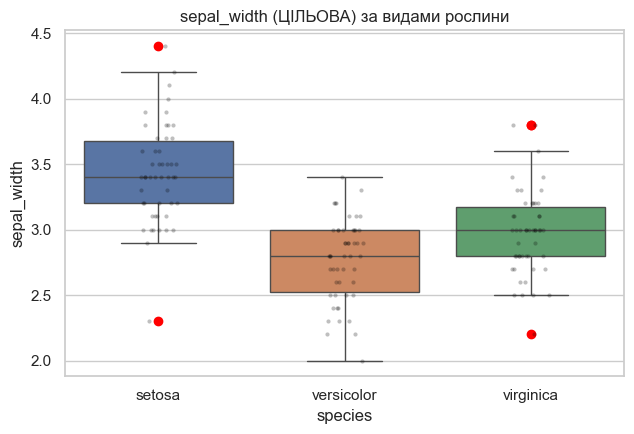

In [21]:
plt.figure(figsize=(6.5, 4.5))
sns.boxplot(data=df, x='species', y='sepal_width', hue='species', palette=palette, legend=False,
            fliersize=6, flierprops=dict(marker='o', markerfacecolor='red', markeredgecolor='red'))
sns.stripplot(data=df, x='species', y='sepal_width', color='black', alpha=0.25, size=3)
plt.title('sepal_width (ЦІЛЬОВА) за видами рослини')
plt.tight_layout()
plt.savefig('06_boxplot_sepal_width_by_species.png', dpi=130, bbox_inches='tight')
plt.show()

**Висновок:** у розрізі видів чітко видно, що *setosa* в середньому має **найширші** чашолистки, *versicolor* — **найвужчі**, *virginica* — проміжні. Global-мінімум (2.0, *versicolor*) виявляється **типовим** для свого виду (в межах віскерів versicolor, не викид), тоді як усередині *setosa* з'являється **новий** нижній викид — 2.3 (не був видний на глобальному boxplot, бо 2.3 повністю "ховається" в загальному міжквартильному розмаху). У *virginica* так само з'являються 3 власні викиди (два по 3.8 та один 2.2), не помітні на глобальному графіку.

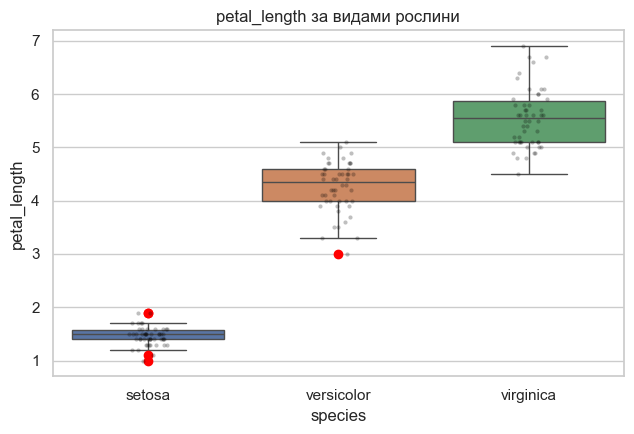

In [22]:
plt.figure(figsize=(6.5, 4.5))
sns.boxplot(data=df, x='species', y='petal_length', hue='species', palette=palette, legend=False,
            fliersize=6, flierprops=dict(marker='o', markerfacecolor='red', markeredgecolor='red'))
sns.stripplot(data=df, x='species', y='petal_length', color='black', alpha=0.25, size=3)
plt.title('petal_length за видами рослини')
plt.tight_layout()
plt.savefig('06b_boxplot_petal_length_by_species.png', dpi=130, bbox_inches='tight')
plt.show()

**Висновок:** три види утворюють практично неперетинні "коробки" (лише *versicolor* та *virginica* злегка стикаються межами). Всередині вузького діапазону *setosa* з'являються власні викиди (короткі 1.0/1.1 і довгі 1.9/1.9 пелюстки), яких глобальний тест не бачив через величезний загальний IQR. У *versicolor* є один нижній викид (3.0).

In [23]:
print("Викиди за правилом 1.5*IQR ОКРЕМО в межах кожного виду:")
for col in num_cols:
    print(f"--- {col} ---")
    for sp, g in df.groupby('species'):
        q1, q3 = g[col].quantile(0.25), g[col].quantile(0.75)
        iqr = q3 - q1
        lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
        out = g[(g[col] < lo) | (g[col] > hi)]
        if len(out):
            print(f"  {sp}: межі=({lo:.2f},{hi:.2f})  викиди={out[col].tolist()}  (idx={out.index.tolist()})")
        else:
            print(f"  {sp}: викидів немає")

Викиди за правилом 1.5*IQR ОКРЕМО в межах кожного виду:
--- sepal_length ---
  setosa: викидів немає
  versicolor: викидів немає
  virginica: межі=(5.21,7.91)  викиди=[4.9]  (idx=[106])
--- sepal_width ---
  setosa: межі=(2.49,4.39)  викиди=[4.4, 2.3]  (idx=[15, 41])
  versicolor: викидів немає
  virginica: межі=(2.24,3.74)  викиди=[3.8, 2.2, 3.8]  (idx=[117, 119, 131])
--- petal_length ---
  setosa: межі=(1.14,1.84)  викиди=[1.1, 1.0, 1.9, 1.9]  (idx=[13, 22, 24, 44])
  versicolor: межі=(3.10,5.50)  викиди=[3.0]  (idx=[98])
  virginica: викидів немає
--- petal_width ---
  setosa: межі=(0.05,0.45)  викиди=[0.5, 0.6]  (idx=[23, 43])
  versicolor: викидів немає
  virginica: викидів немає


### 6.3. Розбір найсуттєвіших випадків

Для кожного суттєвого випадку — (1) чи це можлива помилка, (2) чи допустимо з погляду предметної області, (3) рішення.

In [24]:
candidate_idx = [15, 41, 106, 117, 119, 131, 13, 22, 24, 44, 98]
df.loc[candidate_idx].sort_values('species')

,sepal_length,sepal_width,petal_length,petal_width,species
15,5.7,4.4,1.5,0.4,setosa
41,4.5,2.3,1.3,0.3,setosa
13,4.3,3.0,1.1,0.1,setosa
22,4.6,3.6,1.0,0.2,setosa
24,4.8,3.4,1.9,0.2,setosa
44,5.1,3.8,1.9,0.4,setosa
98,5.1,2.5,3.0,1.1,versicolor
106,4.9,2.5,4.5,1.7,virginica
117,7.7,3.8,6.7,2.2,virginica
119,6.0,2.2,5.0,1.5,virginica


| Випадок | Значення | (1) Можлива помилка? | (2) Допустимо для предметної області? | (3) Рішення |
|---|---|---|---|---|
| `sepal_width`=4.4 (idx 15, *setosa*, глобальний і локальний викид) | найширший чашолисток у наборі | Малоймовірно: інші ознаки цього рядка (petal_length=1.5, petal_width=0.4) типові для *setosa* — жодної внутрішньої суперечності | Так, *setosa* й так має найширші чашолистки в середньому; 4.4 см — правдоподібне фізичне значення | **Залишити.** Природна варіативність в межах виду |
| `sepal_width`=2.3 (idx 41, *setosa*, лише локальний викид, ≈3 σ нижче середнього *setosa*) | найвужчий чашолисток серед *setosa* | Найбільш підозрілий випадок з усіх: усі інші ознаки рядка (sepal_length=4.5, petal_length=1.3, petal_width=0.3) абсолютно типові для *setosa* — аномалія лише в одній ознаці | Фізично можливе значення (не виходить за межі, спостережувані в інших видів), тому виключити природну варіативність не можна | **Залишити, але позначити для перевірки.** Немає прямих доказів помилки (значення не дублюється і не є фізично неможливим), проте варто за можливості звірити з першоджерелом |
| `sepal_length`=4.9 (idx 106, *virginica*, лише локальний викид — точно на межі мін. для виду) | найменша довжина чашолистка серед *virginica* | Малоймовірно: petal_length=4.5 і petal_width=1.7 — цілком у межах типового діапазону *virginica*, отже вид визначено правильно, це не переплутана *versicolor*/*setosa* | Так, це просто менша за розміром особина *virginica*, узгоджена за іншими вимірами | **Залишити.** Внутрішньо узгоджений випадок |
| `sepal_width`=3.8 (idx 117, 131, *virginica*, лише локальні викиди) | широкі чашолистки для *virginica* | Малоймовірно: обидва рядки мають одні з найбільших значень sepal_length (7.7 і 7.9 — максимум у наборі) і petal_length (6.7 і 6.4) — це загалом найбільші квітки, тож ширший чашолисток логічно узгоджений з великим розміром рослини | Так, узгоджується з загальним розміром квітки | **Залишити.** Пропорційна варіативність, не аномалія |
| `petal_length`=1.0/1.1/1.9/1.9 (idx 13,22,24,44, *setosa*, лише локальні викиди) | крайні значення довжини пелюстки в межах *setosa* | Малоймовірно: значення 1.9 трапляється у двох різних рядків з різними іншими ознаками (petal_width 0.2 і 0.4) — це виключає банальне дублювання/копіювання рядка; 1.0 — водночас глобальний мінімум усього набору, узгоджений з дуже малим petal_width=0.2 | Так, це найменші/найбільші, але фізично цілком нормальні пелюстки в межах дуже вузького діапазону *setosa* | **Залишити.** Це просто "хвости" вузького, але справжнього розподілу *setosa* |
| `petal_width`=1.4 (idx 134, *virginica*) — виявлено пізніше, у розділі 7, як **двовимірна** аномалія (не є викидом за жодним boxplot окремо) | найменша ширина пелюстки серед *virginica*, у поєднанні з типовою для *virginica* довжиною | Найбільш вартий уваги "прихований" випадок — стандартний одновимірний IQR його **не бачить**, оскільки саме значення (1.4) — це лише межа (мінімум) розподілу *virginica*, а не викид за IQR | Так, значення в межах спостережуваного діапазону, фізично можливе | **Залишити.** Детальніше обґрунтування — у розділі 7 (аналіз взаємозв'язків) |

**Загальний висновок і рішення:** жодне із виявлених значень **не видаляється, не обмежується (capping) і не трансформується**. Обґрунтування:
1. Усі значення фізично правдоподібні для квітки ірису (додатні, у розумних межах, без нулів чи від'ємних чисел).
2. Кілька "крайніх" значень трапляються у **різних рядках з різними супутніми ознаками** (наприклад, `petal_length=1.9` двічі) — це аргумент проти одноразової помилки введення даних, а не на її користь.
3. Перехресна перевірка інших ознак у "підозрілих" рядках (напр., idx 106, 117, 131) щоразу підтверджує **внутрішню узгодженість** — значення відповідають реальній, хоч і рідкісній, комбінації розмірів квітки.
4. Малий обсяг вибірки (150 рядків, 50 на вид) робить видалення "природної" варіативності ризикованим — це зменшить і без того невелику кількість спостережень та штучно занизить розкид цільової ознаки.
5. **Найважливіший практичний висновок:** пул-рівень (без урахування виду) і рівень видів дають **різні** списки викидів. Це означає, що на етапі побудови регресійної моделі для `sepal_width` варто обов'язково враховувати `species` (як предиктор або через окреме моделювання за групами) — інакше приховані групові ефекти будуть або замасковані, або хибно інтерпретовані як "шум".

## 7. Дослідження взаємозв'язків між ознаками

### Чому обрано саме ці пари ознак

Вибір ґрунтується на кореляційній матриці (нижче) та змістовних міркуваннях:

1. **`petal_length` і `petal_width`** — найвища кореляція в наборі (r≈0.96); обидві ознаки описують **один і той самий орган** (пелюстку), тож очікується, що вони ростуть узгоджено — цікаво перевірити, наскільки сильно, і чи не є одна з ознак **надлишковою** відносно іншої.
2. **`sepal_length` і `petal_length`** — сильна кореляція (r≈0.87) між ознаками **різних органів**; цікаво з'ясувати, чи це відображає загальний "розмір квітки", і чи однаково цей зв'язок проявляється в межах кожного виду.
3. **`sepal_width` (ЦІЛЬОВА ознака) і `petal_length`** — найважливіша пара для подальшого моделювання: саме цей зв'язок і буде частково лежати в основі майбутньої регресії. Кореляція помірна і **від'ємна** на рівні всієї вибірки (r≈−0.43), що прямо суперечить інтуїції "більша квітка — більші всі її частини", тому цю пару необхідно дослідити найглибше.

Оскільки числових ознак усього чотири (невелика кількість), спершу побудуємо **pairplot** для загального огляду, а потім — окремі **scatterplot** для трьох обраних пар.

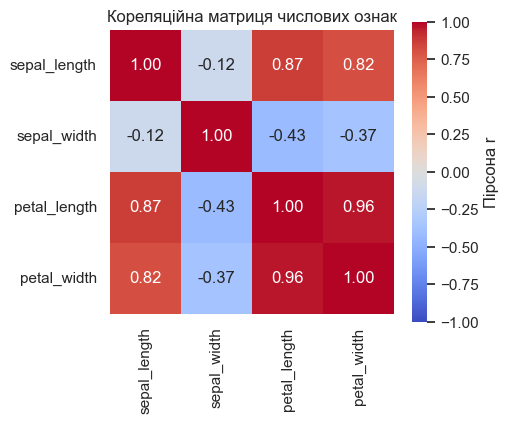

In [25]:
plt.figure(figsize=(5.2, 4.4))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True,
            cbar_kws={'label': "Пірсона r"})
plt.title('Кореляційна матриця числових ознак')
plt.tight_layout()
plt.savefig('07_correlation_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()

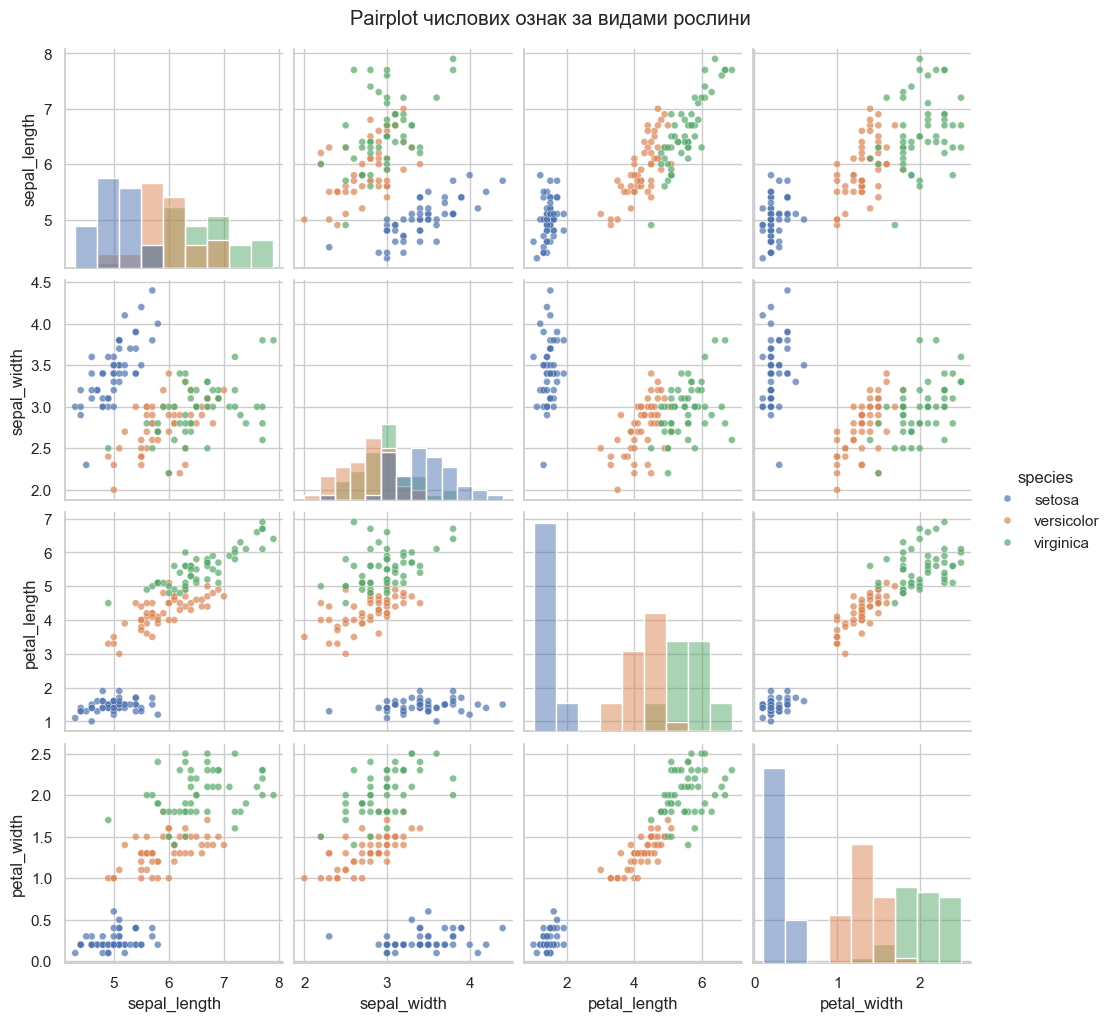

In [26]:
g = sns.pairplot(df, vars=num_cols, hue='species', palette=palette,
                  diag_kind='hist', plot_kws=dict(alpha=0.7, s=25, edgecolor='white', linewidth=0.3))
g.fig.suptitle("Pairplot числових ознак за видами рослини", y=1.02)
g.savefig('08_pairplot.png', dpi=130, bbox_inches='tight')
plt.show()

**Загальний огляд pairplot:** одразу видно, що *setosa* (сині точки) в переважній більшості панелей утворює чітко відокремлену групу. У панелях з `petal_length`/`petal_width` зв'язки виглядають дуже лінійними та тісними. У панелях із `sepal_width` картина інша: якщо дивитися на всі три кольори одразу, загальний тренд ніби спадний, хоча кожна кольорова хмара точок окремо радше зростає — це вже видно неозброєним оком і буде детально проаналізовано нижче.

### 7.1. `petal_length` vs `petal_width`

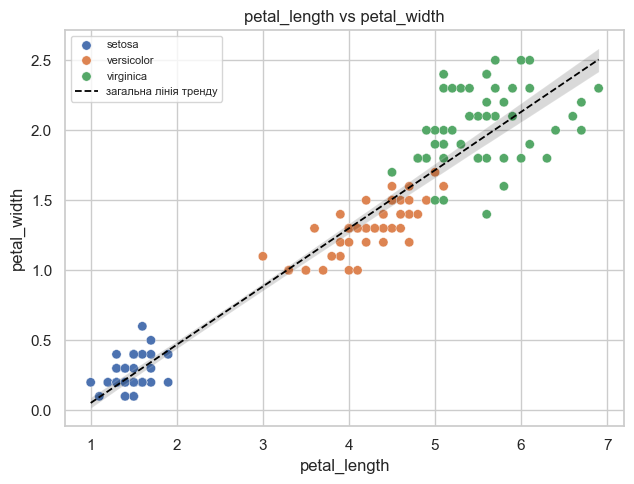

In [27]:
plt.figure(figsize=(6.5, 5))
sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species', palette=palette,
                 s=45, edgecolor='white', linewidth=0.3)
sns.regplot(data=df, x='petal_length', y='petal_width', scatter=False, color='black',
            line_kws=dict(lw=1.3, ls='--'), label='загальна лінія тренду')
plt.title('petal_length vs petal_width')
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig('09_scatter_petal_length_width.png', dpi=130, bbox_inches='tight')
plt.show()

In [28]:
print("Кореляція в межах кожного виду:")
for sp, g in df.groupby('species'):
    print(f"  {sp}: r = {g['petal_length'].corr(g['petal_width']):.3f}")

Кореляція в межах кожного виду:
  setosa: r = 0.332
  versicolor: r = 0.787
  virginica: r = 0.322


**Висновки:**
- **Напрямок:** чітко позитивний — довші пелюстки одночасно й ширші.
- **Лінійність:** загалом дуже лінійна залежність (r=0.963), точки щільно прилягають до єдиної прямої.
- **Групи:** три види розташовані послідовно **вздовж однієї й тієї самої лінії** (*setosa* → *versicolor* → *virginica*), майже не перекриваючись.
- **Аномалії:** одна точка *virginica* (petal_length≈5.6, petal_width=1.4) помітно нижче основної хмари свого виду — це найменше значення `petal_width` серед усіх *virginica*, при цьому типова довжина пелюстки для цього виду; детальний розбір — у таблиці розділу 6.3.
- **Надлишковість:** кореляція в межах КОЖНОГО виду окремо суттєво слабша (0.32 / 0.79 / 0.32), ніж загальна (0.96) — тобто дуже висока пул-кореляція значною мірою "роздута" самим фактом розділення видів уздовж діагоналі, а не тим, що вони ідеально пропорційні одна одній всередині виду. Проте загальна кореляція все одно залишається дуже високою, тож **при лінійному моделюванні варто пам'ятати про ризик мультиколінеарності**, якщо обидві ознаки використовувати одночасно.

### 7.2. `sepal_length` vs `petal_length`

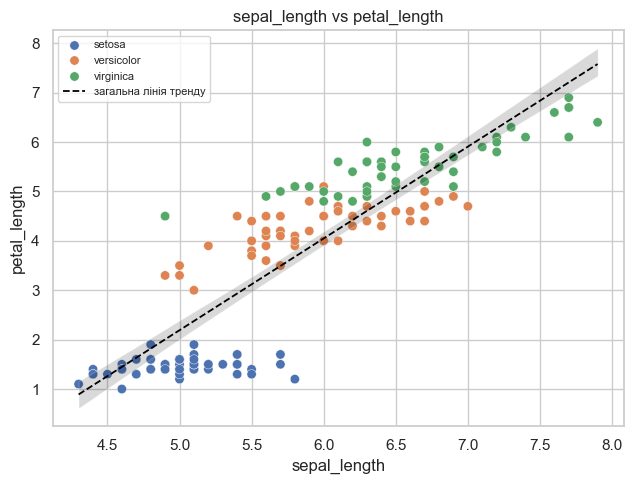

In [29]:
plt.figure(figsize=(6.5, 5))
sns.scatterplot(data=df, x='sepal_length', y='petal_length', hue='species', palette=palette,
                 s=45, edgecolor='white', linewidth=0.3)
sns.regplot(data=df, x='sepal_length', y='petal_length', scatter=False, color='black',
            line_kws=dict(lw=1.3, ls='--'), label='загальна лінія тренду')
plt.title('sepal_length vs petal_length')
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig('10_scatter_sepal_length_petal_length.png', dpi=130, bbox_inches='tight')
plt.show()

In [30]:
print("Кореляція в межах кожного виду:")
for sp, g in df.groupby('species'):
    print(f"  {sp}: r = {g['sepal_length'].corr(g['petal_length']):.3f}")

Кореляція в межах кожного виду:
  setosa: r = 0.267
  versicolor: r = 0.754
  virginica: r = 0.864


**Висновки:**
- **Напрямок:** позитивний.
- **Лінійність:** загалом лінійна (r=0.872), проте в межах *setosa* зв'язок значно слабший (r=0.267) — тобто поза межами вузького діапазону *setosa* довжина чашолистка й пелюстки узгоджено ростуть, а всередині самого виду *setosa* — майже незалежні одна від одної.
- **Групи:** *setosa* чітко відокремлена внизу зліва; *versicolor* і *virginica* суттєво перекриваються й продовжують один загальний тренд.
- **Аномалії:** точка *virginica* з sepal_length=4.9 (розділ 6.3, idx 106) лежить лівіше основної хмари свого виду за віссю X, проте її petal_length=4.5 узгоджене з видом — тобто це не суперечність, а справді менша особина.
- **Надлишковість:** помірна кореляція за наявності суттєво різної поведінки в межах *setosa* означає, що ця пара **менш надлишкова**, ніж `petal_length`/`petal_width` — обидві ознаки варто залишити як окремі предиктори.

### 7.3. `sepal_width` (ЦІЛЬОВА) vs `petal_length` — парадокс Сімпсона

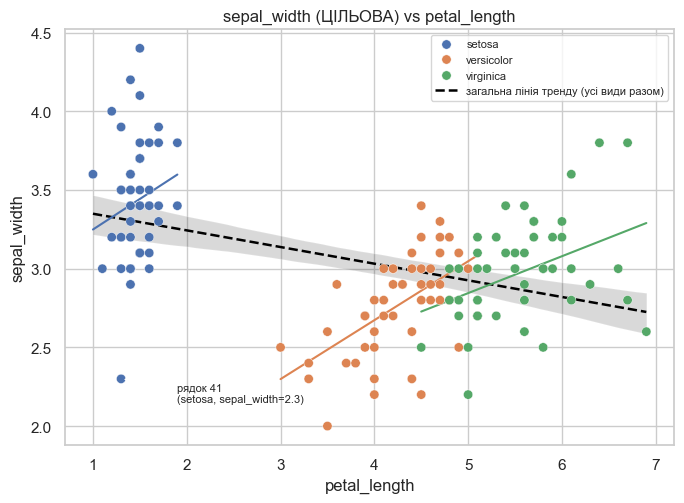

In [31]:
plt.figure(figsize=(7, 5.2))
sns.scatterplot(data=df, x='petal_length', y='sepal_width', hue='species', palette=palette,
                 s=45, edgecolor='white', linewidth=0.3, zorder=3)
sns.regplot(data=df, x='petal_length', y='sepal_width', scatter=False, color='black',
            line_kws=dict(lw=1.8, ls='--'), label='загальна лінія тренду (усі види разом)')
for sp in df['species'].unique():
    gsub = df[df['species'] == sp]
    sns.regplot(data=gsub, x='petal_length', y='sepal_width', scatter=False,
                color=palette[sp], line_kws=dict(lw=1.5), ci=None)
p41 = df.loc[41]
plt.annotate('рядок 41\n(setosa, sepal_width=2.3)', xy=(p41['petal_length'], p41['sepal_width']),
             xytext=(p41['petal_length']+0.6, p41['sepal_width']-0.15),
             fontsize=8, arrowprops=dict(arrowstyle='->', lw=0.8))
plt.title("sepal_width (ЦІЛЬОВА) vs petal_length")
plt.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.savefig('11_scatter_sepalwidth_petallength_simpson.png', dpi=130, bbox_inches='tight')
plt.show()

In [32]:
print("Кореляція sepal_width vs petal_length:")
print("  Загальна (всі види разом): r =", round(df['sepal_width'].corr(df['petal_length']), 3))
for sp, g in df.groupby('species'):
    print(f"  {sp}: r = {g['sepal_width'].corr(g['petal_length']):.3f}")

Кореляція sepal_width vs petal_length:
  Загальна (всі види разом): r = -0.428
  setosa: r = 0.178
  versicolor: r = 0.561
  virginica: r = 0.401


**Висновки:**
- **Напрямок:** на рівні всієї вибірки — **від'ємний** (r=−0.428, чорна пунктирна лінія спадає), проте в межах **кожного окремого виду** — **додатний** (від +0.18 у *setosa* до +0.56 у *versicolor*). Це класичний **парадокс Сімпсона**: агрегування трьох різних груп в одну вибірку розвертає знак залежності, оскільки *setosa* (короткі пелюстки, широкі чашолистки) як група розташована окремо від *versicolor*/*virginica* (довші пелюстки, вужчі чашолистки).
- **Лінійність:** у межах кожного виду зв'язок приблизно лінійний, хоча й зашумлений (особливо в *setosa*, де r лише 0.18).
- **Групи:** три чітко відокремлені хмари точок — саме вони й формують парадокс.
- **Аномалії:** рядок 41 (*setosa*, sepal_width=2.3) позначено на графіку — він помітно нижчий за основну хмару свого виду відносно локального (синього) тренду; це той самий випадок, що й у розділі 6.3.
- **Надлишковість:** ознаки **не є надлишковими** одна щодо одної — навпаки, вони несуть частково суперечливу інформацію залежно від того, чи відомий вид рослини. Це має **пряме значення для майбутньої моделі**: якщо будувати регресію `sepal_width ~ petal_length` без урахування `species`, модель "навчиться" хибному від'ємному напрямку залежності, тоді як справжній (внутрішньовидовий) зв'язок — додатний. Тому `species` обов'язково потрібно включити до майбутньої моделі як предиктор (або будувати окремі моделі за видами).

### Підсумок розділу 7

| Пара ознак | Загальний r | r у межах видів | Напрямок | Лінійність | Групи | Аномалії | Надлишковість |
|---|---|---|---|---|---|---|---|
| `petal_length` vs `petal_width` | **0.963** | 0.32 / 0.79 / 0.32 | позитивний | дуже лінійна | 3 послідовні вздовж прямої | 1 точка *virginica* (idx 134) | висока — ризик мультиколінеарності |
| `sepal_length` vs `petal_length` | 0.872 | 0.27 / 0.75 / 0.86 | позитивний | лінійна (слабша в *setosa*) | *setosa* відокремлена, решта перекриваються | idx 106 (пояснена) | помірна, не критична |
| `sepal_width` (ЦІЛЬ) vs `petal_length` | **−0.428** | **+0.18 / +0.56 / +0.40** | **різний напрямок! (парадокс Сімпсона)** | лінійна в межах виду | 3 чіткі групи | idx 41 | не надлишкові — критично важливо для моделі |

## 8. Загальний підсумок

| Етап аналізу | Ключовий результат |
|---|---|
| Розмірність | 150 рядків × 5 стовпців |
| Типи стовпців (за змістом) | 4 числові неперервні + 1 номінальна категоріальна (`species`) |
| Пропущені значення | 0 (0.0%) |
| Повні дублікати | 1 (рядки 101, 142) |
| Розподіли | `sepal_*` — близькі до симетричних, одномодальні; `petal_*` — виражено бімодальні/групові через відмінності видів |
| Викиди (глобальний IQR) | лише `sepal_width` (4 точки) |
| Викиди (IQR у межах виду) | додатково виявлено у `sepal_width`, `sepal_length`, `petal_length`, `petal_width` — усі пояснені як природна варіативність, жоден не видалено |
| Найважливіший зв'язок | `sepal_width` (ціль) має **різний знак** кореляції з `petal_length`/`petal_width` залежно від того, враховано вид рослини чи ні (парадокс Сімпсона) |
| Надлишковість ознак | `petal_length` і `petal_width` сильно корелюють на рівні вибірки (можливий ризик мультиколінеарності); інші пари — менш надлишкові |

**Головні висновки для підготовки до моделювання:**
1. Один повний дублікат рядка — розглянути видалення перед train/test split.
2. `species` кодувати one-hot (без природного порядку) — і **обов'язково включити до моделі**, оскільки без цього виникає парадокс Сімпсона для цільової ознаки.
3. Жодне з виявлених екстремальних значень не видалено — усі пояснені як природна біологічна варіативність або внутрішньо узгоджені зі своїм видом.
4. При виборі складу ознак для лінійної регресії варто врахувати високу кореляцію `petal_length`/`petal_width` (мультиколінеарність) — можливо, обмежитися однією з них або застосувати регуляризацію.
5. Аналіз довів, що **пул-рівень (без урахування виду) систематично спотворює висновки** — і щодо викидів, і щодо напрямку залежностей — тому подальший аналіз і моделювання мають враховувати структуру видів.

Ці спостереження буде використано на наступних етапах роботи (кодування ознак, побудова моделі регресії для `sepal_width`), які виходять за межі поточної практичної роботи.

## 6. Кореляційний аналіз

Для вивчення лінійних та монотонних залежностей між числовими ознаками обчислено матриці кореляції Пірсона та Спірмена.


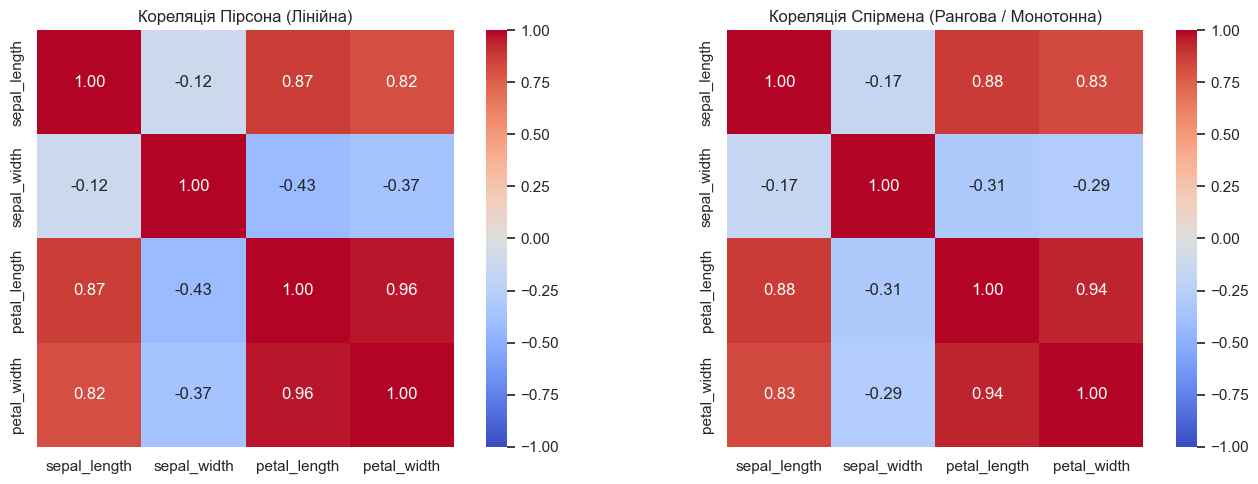

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

# Обчислення кореляційних матриць
corr_pearson = df[num_cols].corr(method='pearson')
corr_spearman = df[num_cols].corr(method='spearman')

# Візуалізація
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(corr_pearson, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0], square=True)
axes[0].set_title('Кореляція Пірсона (Лінійна)')

sns.heatmap(corr_spearman, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=axes[1], square=True)
axes[1].set_title('Кореляція Спірмена (Рангова / Монотонна)')

plt.tight_layout()
plt.show()

### 6.1. Аналіз кореляційних зв'язків

* **Найбільша додатна кореляція:** пара `petal_length` та `petal_width` ($r = 0.96$, $r_s = 0.94$). Це свідчить про майже лінійну залежність між довжиною та шириною пелюстки.Також високу додатну кореляцію демонструють `sepal_length` і `petal_length` ($r = 0.87$).
* **Найбільша від'ємна кореляція:** пара `sepal_width` та `petal_length` ($r = -0.43$, $r_s = -0.31$).
* **Потенційно сильно пов'язані ознаки (мультиколінеарність):** `petal_length`, `petal_width` та `sepal_length` утворюють групу висококорельованих змінних ($r > 0.8$). Використання їх усіх разом у лінійній регресії може призвести до мультиколінеарності.
* **Зв'язки з цільовою змінною (`sepal_width`):** на загальному рівні `sepal_width` має помірний від'ємний зв'язок із `petal_length` ($r = -0.43$) та `petal_width` ($r = -0.37$), а також слабкий від'ємний зв'язок із `sepal_length` ($r = -0.12$).
* **Порівняння Пірсона та Спірмена:** коефіцієнти Пірсона та Спірмена мають подібні значення та напрямки, що підтверджує монотонний характер більшості лінійних залежностей. Проте Спірмен показує трохи нижчі значення для пар із `sepal_width`, що може вказувати на нелінійний або мультимодальний характер розподілу через наявність трьох різних видів ірисів.

> **Важливо:** Кореляція показує лише статистичний зв'язок, а не причинно-наслідковий. Значення кореляції `sepal_width` із `sepal_length` близьке до нуля ($r = -0.12$), але це не означає відсутність залежності.

## 7. Аналіз зв'язку ознак із цільовою змінною (`sepal_width`)

Оскільки задача є регресійною (цільова змінна `sepal_width` є неперервною), дослідимо її зв'язок із числовими предикторами за допомогою диаграм розсіювання (scatterplot) та з категоріальним предиктором `species` за допомогою графіків boxplot.

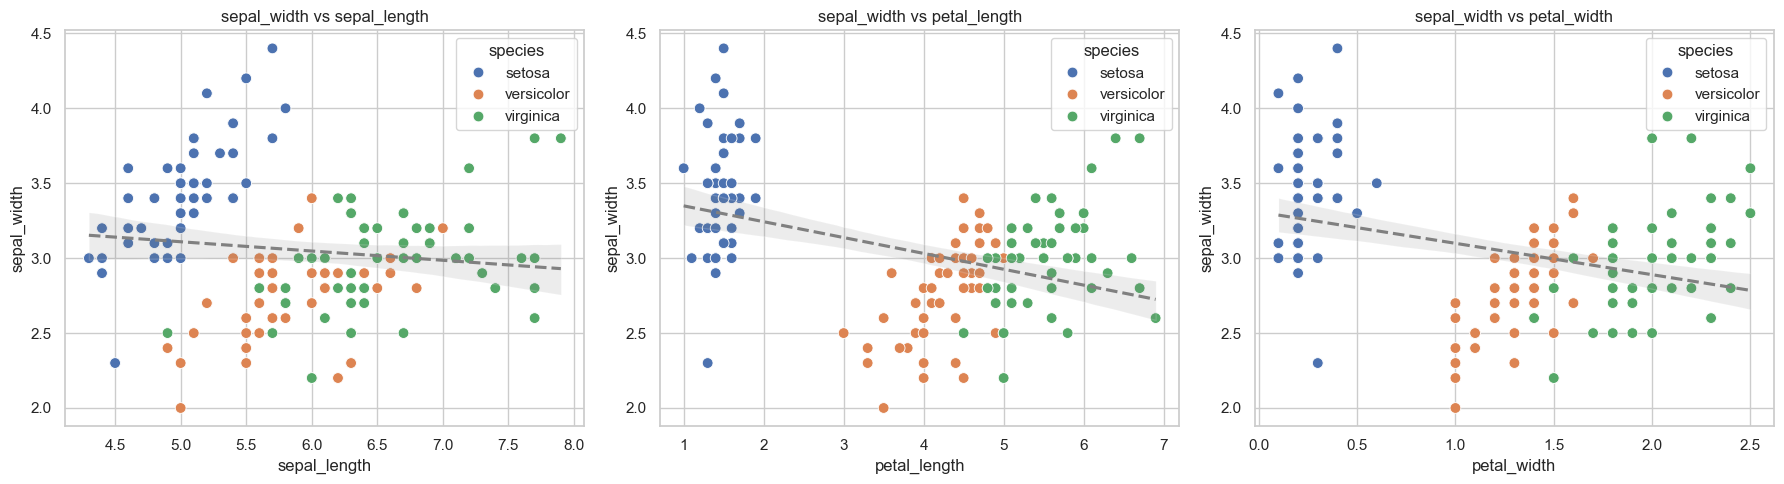

C:\Users\Yaroslav\AppData\Local\Temp\ipykernel_12388\2372374535.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y='sepal_width', palette=palette)


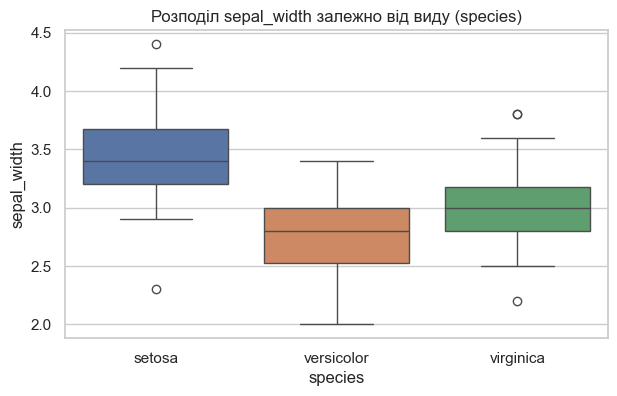

In [34]:
# Scatterplots для числових ознак
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, col in enumerate(['sepal_length', 'petal_length', 'petal_width']):
    sns.scatterplot(data=df, x=col, y='sepal_width', hue='species', palette=palette, ax=axes[idx], s=60)
    sns.regplot(data=df, x=col, y='sepal_width', scatter=False, ax=axes[idx], color='gray', line_kws={'linestyle':'--'})
    axes[idx].set_title(f'sepal_width vs {col}')

plt.tight_layout()
plt.show()

# Boxplot для категоріальної ознаки species
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='species', y='sepal_width', palette=palette)
plt.title('Розподіл sepal_width залежно від виду (species)')
plt.show()

### 7.1. Висновки щодо зв'язку з цільовою змінною

* **Парадокс Сімпсона (Simpson's Paradox):** Загальний графік залежності `sepal_width` від `sepal_length` показує слабку від'ємну кореляцію ($r = -0.12$). Однак у розрізі окремих видів (*Setosa*, *Versicolor*, *Virginica*) спостерігається чіткий **додатний** лінійний зв'язок. Це демонструє, що групуюча ознака `species` критично змінює характер залежностей.
* **Вплив виду (`species`):** Вид *Setosa* суттєво відрізняється від інших — він має значно більшу ширину чашолистка (медіана ~3.4 см) при меншій довжині пелюсток. Для *Versicolor* та *Virginica* значення `sepal_width` значно нижчі (медіани ~2.8 см та ~3.0 см відповідно).
* **Нелінійність:** Загальна залежність між шириною чашолистка та розмірами пелюстки є нелінійною та розпадається на два виразні кластери (*Setosa* проти *Versicolor/Virginica*).

## 8. Формулювання гіпотез

На основі проведеного статистичного та візуального аналізу сформульовано такі гіпотези щодо набору даних:

* **Гіпотеза 1 (Про мультиколінеарність та надлишковість даних):** 
  Ознаки `petal_length` та `petal_width` мають дуже високу кореляцію ($r = 0.96$). Вони містять практично дубльовану інформацію про розмір пелюстки, тому для запобігання перенавчанню та мультиколінеарності майбутньої регресійної моделі одну з цих ознак доцільно вилучити або об'єднати за допомогою зменшення вимірності (наприклад, PCA).
* **Гіпотеза 2 (Про ключову роль категоріальної ознаки `species`):** 
  Використання числових ознак без урахування `species` призведе до низької якості прогнозування `sepal_width` через Парадокс Сімпсона. Включення `species` (через One-Hot Encoding) є обов'язковим для побудови адекватної регресійної моделі.
* **Гіпотеза 3 (Про природний характер екстремальних значень):** 
  Визначені під час Boxplot-аналізу високі значення `sepal_width` (понад 4.0 см) належать виключно виду *Setosa* і не є помилками вимірювання чи технічними викидами, а природною біологічною мінливістю даного виду.

## 9. Планування попередньої обробки даних (Preprocessing Plan)

Відповідно до проведеного розвідувального аналізу (EDA) та аудиту даних, складено план попередньої обробки. 

**Щодо обробки пропущених значень:** На етапі первинного аудиту було встановлено, що у наборі даних Iris **пропущені значення (NaN/Null) повністю відсутні**. Згідно з правилом "не застосовувати операції, потреби в яких не виявлено", стратегії імпутації (медіаною, середнім, модою тощо) або видалення об'єктів/ознак через пропуски **не застосовуються**.

Усі параметри для перетворень (наприклад, середнє та стандартне відхилення для масштабування) будуть оцінюватися **виключно за навчальною вибіркою (Train)** для запобігання витоку даних (data leakage).

### План перетворень (Таблиця)

| Ознака / Проблема | Рішення | Обґрунтування (Яку проблему вирішує) |
| :--- | :--- | :--- |
| **Весь датасет / Наявність повних дублікатів** | Видалення повних дублікатів (`drop_duplicates`), залишаючи перший знайдений екземпляр. | Під час аудиту виявлено 1 дублікат (рядки 101 та 142). Операція вирішує проблему штучного завищення ваги одного спостереження під час навчання та знижує ризик потрапляння однакових даних і в train, і в test. |
| **Весь датасет / Ризик витоку даних (Data Leakage)** | Розділення даних на навчальну (Train) та тестову (Test) вибірки **до** початку будь-яких перетворень ознак. | Вирішує проблему необ'єктивної оцінки моделі. Гарантує, що всі параметри препроцесингу (масштабування) розраховуватимуться лише на тренувальних даних. |
| **Ознака `species` / Нечисловий (категоріальний) формат** | Перетворення за допомогою One-Hot Encoding (або Dummy-кодування з видаленням першого стовпця - `drop_first=True`). | Регресійні моделі працюють лише з числовими матрицями. OHE вирішує проблему перетворення номінативної ознаки у числа без надання їй хибного математичного порядку (1 < 2 < 3), що сталося б при звичайному Label Encoding. |
| **Ознаки `petal_length`, `petal_width` / Сильна мультиколінеарність** | Видалення ознаки `petal_width` (або об'єднання через метод головних компонент - PCA). | Кореляція Пірсона між цими ознаками $r = 0.96$. Операція вирішує проблему мультиколінеарності, яка робить коефіцієнти лінійної регресії нестабільними, чутливими до шуму та ускладнює їх інтерпретацію. |
| **Усі числові предиктори / Різний масштаб ознак** | Масштабування ознак за допомогою `StandardScaler` (стандартизація до середнього 0 та дисперсії 1). | Значення довжини чашолистка і пелюсток мають різний розмах. Операція вирішує проблему домінування ознак з більшими абсолютними значеннями та допомагає градієнтним алгоритмам збігатися швидше і коректніше. |

## 10. Обробка дублікатів та неінформативних ознак

### 10.1. Аналіз виявлених дублікатів
Під час первинного аудиту було виявлено 1 повний дублікат (рядки 101 та 142 зі значеннями: `sepal_length`=5.8, `sepal_width`=2.7, `petal_length`=5.1, `petal_width`=1.9, `species`='virginica'). 

**Рішення:** Залишити дублікат у наборі даних.
**Обґрунтування:** З огляду на предметну область (ботанічні вимірювання), точність даних становить лише один десятковий знак (до міліметрів). У популяції зі 150 квіток імовірність того, що дві різні рослини одного виду матимуть однакові розміри з точністю до міліметра, є досить високою. Отже, це різні об'єкти з однаковими значеннями ознак, а не помилкове дублювання (технічний збій чи повторне введення). Видалення призведе до втрати реального біологічного спостереження.

### 10.2. Робота з неінформативними ознаками
У класичному датасеті Iris (залежно від джерела завантаження, наприклад, з Kaggle) може бути присутня колонка `Id`. 

* **Технічні ідентифікатори:** Якщо стовпець `Id` (або `Unnamed: 0`) присутній, його необхідно **видалити**. 
  * *Причина:* Це службове поле, яке не несе жодної предиктивної цінності та є технічним ідентифікатором рядка. Залишення цієї ознаки може призвести до хибного виявлення "закономірностей" алгоритмом.
* **Константні стовпці:** Відсутні (всі ознаки мають дисперсію > 0).
* **Ознаки з надзвичайно високою кардинальністю:** Відсутні (всі ознаки є або неперервними числовими, або мають 3 категорії).

In [10]:
# Перевірка на наявність технічних ідентифікаторів та їх видалення, якщо вони є
if 'Id' in df.columns:
    df = df.drop(columns=['Id'])
    print("Службове поле 'Id' успішно видалено.")
elif 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
    print("Службове поле 'Unnamed: 0' успішно видалено.")
else:
    print("Технічних ідентифікаторів у наборі даних не виявлено.")

Технічних ідентифікаторів у наборі даних не виявлено.


## 11. Обробка аномальних значень (викидів)

Під час побудови Boxplot у розділі 7 були виявлені точки, що виходять за межі "вусів" (whiskers) для ознаки `sepal_width` (значення понад 4.0 см та менше 2.2 см). 

**Рішення:** Залишити виявлені "аномалії" **без змін**.

**Обґрунтування з урахуванням предметної області:** 
Високі значення ширини чашолистка (екстремальні максимуми) належать виключно до виду *Iris Setosa*. Ботанічно цей вид характеризується ширшими, але коротшими чашолистками порівняно з *Versicolor* та *Virginica*. Отже, ці значення **не є помилками вимірювання чи технічними збоями**, а відображають природну біологічну мінливість (варіативність) цього виду. 

Застосування методів видалення, обмеження (capping) чи логарифмічної трансформації у цьому випадку є помилковим, оскільки це призведе до штучного спотворення природного розподілу даних та втрати інформації, критичної для коректної роботи регресійної моделі (особливо з урахуванням групуючої ознаки `species`).

## 12. Масштабування числових ознак

**Чи потрібне масштабування?**
Так, масштабування необхідне. Хоча для класичної лінійної регресії (МНК) масштабування математично не змінює якість прогнозу (метрику $R^2$), воно є обов'язковим для:
1. **Регуляризації:** Якщо в подальшому будуть використовуватися моделі з регуляризацією (Ridge, Lasso, ElasticNet), ознаки з більшим абсолютним розмахом (як `sepal_length` ~ 4.3-7.9) отримуватимуть несправедливо більшу вагу у функції штрафу порівняно з ознаками з меншим розмахом (`petal_width` ~ 0.1-2.5).
2. **Інтерпретації коефіцієнтів:** Масштабування дозволить безпосередньо порівнювати коефіцієнти лінійної регресії між собою, щоб визначити, яка ознака має найбільший вплив на цільову змінну `sepal_width`.

**Обраний підхід:** `StandardScaler` (Стандартизація).

**Обґрунтування вибору:**
* Дані не містять технічних чи помилкових "важких" викидів (як було доведено в попередньому розділі). Тому використання `RobustScaler`, стійкого до сильних аномалій, не є обов'язковим.
* Розподіл ознак (зокрема `sepal_length`) є близьким до нормального. `StandardScaler` відцентрує дані навколо нуля (середнє = 0) і приведе їх до одиничної дисперсії (стандартне відхилення = 1), що є ідеальною умовою для оптимізації ваг у більшості алгоритмів машинного навчання.
* `MinMaxScaler` був би менш доцільним, оскільки він жорстко стискає дані в діапазон [0, 1] і є вкрай чутливим навіть до природних екстремальних значень, які присутні у виді *Setosa*.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Формуємо матрицю ознак (X) та вектор цільової змінної (y)
# Відповідно до гіпотези 1, вилучаємо petal_width через мультиколінеарність
X = df.drop(columns=['sepal_width', 'petal_width'])
y = df['sepal_width']

# OHE для категоріальної ознаки species (до розбиття, оскільки це зміна структури таблиці)
X = pd.get_dummies(X, columns=['species'], drop_first=True)

# 1. Розбиття на train та test (запобігання Data Leakage)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Масштабування
scaler = StandardScaler()

# Визначаємо числові стовпці для масштабування (без закодованих категорій)
num_cols_to_scale = ['sepal_length', 'petal_length']

# Навчаємо scaler ТІЛЬКИ на X_train та трансформуємо
X_train_scaled = X_train.copy()
X_train_scaled[num_cols_to_scale] = scaler.fit_transform(X_train[num_cols_to_scale])

# Застосовуємо навчений scaler до X_test (без fit!)
X_test_scaled = X_test.copy()
X_test_scaled[num_cols_to_scale] = scaler.transform(X_test[num_cols_to_scale])

print("Форма X_train_scaled:", X_train_scaled.shape)
print("Форма X_test_scaled:", X_test_scaled.shape)
display(X_train_scaled.head())

Форма X_train_scaled: (120, 4)
Форма X_test_scaled: (30, 4)


,sepal_length,petal_length,species_versicolor,species_virginica
22,-1.473937,-1.562535,False,False
15,-0.133071,-1.276006,False,False
65,1.085898,0.385858,True,False
11,-1.230143,-1.218701,False,False
42,-1.717731,-1.390618,False,False


## 13. Кодування категоріальних ознак

Єдиною категоріальною ознакою в наборі даних Iris є `species` (вид ірису: *setosa*, *versicolor*, *virginica*).

* **Тип ознаки:** Номінальна (категорії не мають логічного чи математичного порядку, тобто *setosa* не "більша" і не "менша" за *virginica*).
* **Обраний спосіб кодування:** `OneHotEncoder` (з параметром видалення першої категорії `drop='first'`).
* **Обґрунтування:** Використання `OrdinalEncoder` або `LabelEncoder` (який призначений для цільової змінної) створило б хибний порядок (0 < 1 < 2), що погіршило б роботу регресійної моделі. One-Hot Encoding створює окремі бінарні стовпці для категорій. Використання `drop='first'` дозволяє уникнути "пастки фіктивних змінних" (dummy variable trap) — ідеальної мультиколінеарності між новими стовпцями, що є критичним для лінійної регресії.
* **Висока кардинальність:** Відсутня. Ознака має лише 3 унікальні значення, тому об'єднання рідкісних категорій не потрібне.

## 14. Побудова пайплайна попередньої обробки

Для забезпечення відтворюваності, уникнення витоку даних (data leakage) та зручності розгортання моделі, всі кроки попередньої обробки об'єднано у `Pipeline` та `ColumnTransformer`.

Згідно з висновками 8-го розділу, ознака `petal_width` вилучається через сильну мультиколінеарність. Формуємо пайплайн для ознак `sepal_length`, `petal_length` (числові) та `species` (категоріальна).

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# 1. Формування X та y (вилучаємо petal_width)
X = df[['sepal_length', 'petal_length', 'species']]
y = df['sepal_width']

# 2. Розбиття даних на train та test ДО будь-яких перетворень!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Визначаємо списки ознак за типами
numeric_features = ['sepal_length', 'petal_length']
categorical_features = ['species']

# 3. Створення пайплайну для числових ознак
# Хоча пропусків немає, додавання SimpleImputer є хорошою практикою для стійкості пайплайну на нових даних
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 4. Створення пайплайну для категоріальних ознак
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False))
])

# 5. Об'єднання в єдиний ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 6. Навчання та трансформація
# Параметри розраховуються ТІЛЬКИ на X_train
X_train_prepared = preprocessor.fit_transform(X_train)
# До тестової вибірки застосовується лише трансформація!
X_test_prepared = preprocessor.transform(X_test)

## 15. Перевірка підготовленого набору даних

Перевіримо результати роботи пайплайну, щоб переконатися у відсутності помилок.

In [7]:
# Отримання назв нових ознак
feature_names = preprocessor.get_feature_names_out()

# Перетворення масивів NumPy назад у DataFrame для зручності перевірки
X_train_prep_df = pd.DataFrame(X_train_prepared, columns=feature_names, index=X_train.index)
X_test_prep_df = pd.DataFrame(X_test_prepared, columns=feature_names, index=X_test.index)

print("--- (1) Розмірність вибірок ---")
print(f"X_train_prepared: {X_train_prep_df.shape}")
print(f"X_test_prepared:  {X_test_prep_df.shape}\n")

print("--- (2) Відсутність неочікуваних пропущених значень ---")
print(f"Пропусків у Train: {X_train_prep_df.isna().sum().sum()}")
print(f"Пропусків у Test:  {X_test_prep_df.isna().sum().sum()}\n")

print("--- (3, 4) Кількість та назви отриманих ознак ---")
print(f"Кількість ознак: {len(feature_names)}")
print(f"Назви ознак: {list(feature_names)}\n")

print("--- (5) Відсутність очевидних помилок (Head Train) ---")
display(X_train_prep_df.head(3))

--- (1) Розмірність вибірок ---
X_train_prepared: (120, 4)
X_test_prepared:  (30, 4)

--- (2) Відсутність неочікуваних пропущених значень ---
Пропусків у Train: 0
Пропусків у Test:  0

--- (3, 4) Кількість та назви отриманих ознак ---
Кількість ознак: 4
Назви ознак: ['num__sepal_length', 'num__petal_length', 'cat__species_versicolor', 'cat__species_virginica']

--- (5) Відсутність очевидних помилок (Head Train) ---


,num__sepal_length,num__petal_length,cat__species_versicolor,cat__species_virginica
22,-1.473937,-1.562535,0.0,0.0
15,-0.133071,-1.276006,0.0,0.0
65,1.085898,0.385858,1.0,0.0


### 15.1. Висновки щодо перевірки підготовлених даних

1. **Розмірність:** Вибірки успішно розділені та зберегли кількість рядків (Train: 80%, Test: 20%).
2. **Пропуски:** Відсутні (0 пропусків у обох вибірках).
3. **Кількість ознак:** Збільшилася з 3 (у вхідному `X`) до 4. 
   * *Пояснення збільшення:* Дві числові ознаки (`sepal_length`, `petal_length`) залишилися. Одна категоріальна ознака `species` (3 категорії) була перетворена за допомогою One-Hot Encoder з параметром `drop='first'`. Відповідно, замість 1 стовпця утворилося 2 нові бінарні стовпці (`species_versicolor`, `species_virginica`). Разом: $2 + 2 = 4$ ознаки.
4. **Назви ознак:** Зрозумілі та відображають проведені трансформації (напр., `num__sepal_length`, `cat__species_versicolor`).
5. **Трансформації:** Значення числових ознак успішно відцентровані навколо нуля (стандартизація). Бінарні ознаки мають значення 0.0 або 1.0.
6. **Ізольованість Test:** Тестова вибірка успішно оброблена тим самим об'єктом `preprocessor` без перенавчання (використано виключно метод `transform`). Дані готові до подачі в ML-модель.

## 16. Обґрунтування прийнятих рішень (Підсумкова таблиця)

У таблиці нижче наведено ключові рішення щодо попередньої обробки даних із зазначенням альтернатив, які розглядалися, але були відхилені, а також ролі штучного інтелекту в їх прийнятті.

| Проблема / ознака | Прийняте рішення | Підстава (Логіка: властивість $\rightarrow$ рішення $\rightarrow$ перевірка) |
| :--- | :--- | :--- |
| **Пропуски в даних** | Відмова від імпутації. | **Властивість:** Згідно з методом `df.info()`, пропусків у датасеті немає. **Відхилена альтернатива:** Додавання складної логіки заповнення. **Перевірка:** `df.isna().sum()`. |
| **Дублікати (1 рядок)** | Залишити в наборі даних. | **Властивість:** Точність вимірювання — до десятих (мм). **Логіка:** Це різні квітки з однаковими розмірами, а не технічна помилка введення. **Перевірка:** Логічний аналіз предметної області (біологія). |
| **Викиди в `sepal_width`** | Залишити без змін. *(Рішення запропоновано ШІ після аналізу Boxplot)* | **Властивість:** Значення > 4.0 належали виключно виду *Setosa*. **Відхилена альтернатива:** Видалення або "обрізання" (capping). **Логіка:** Це природна варіативність виду, а не помилка. Штучне обрізання спотворило б дані. |
| **Мультиколінеарність (`petal_length` та `petal_width`)** | Виключення `petal_width`. | **Властивість:** Кореляція Пірсона $r = 0.96$. **Відхилена альтернатива:** Використання PCA. **Логіка:** Оскільки ознак мало, просте видалення однієї з висококорельованих ознак є простішим і зберігає інтерпретованість моделі. **Перевірка:** Кореляційна матриця (Heatmap). |
| **Категорія `species`** | One-Hot Encoding (`drop='first'`). | **Властивість:** Ознака є номінальною (без природного порядку). **Відхилена альтернатива:** `LabelEncoder` (0, 1, 2) — створив би хибний математичний зв'язок. **Логіка:** Перетворення на бінарні вектори без "пастки фіктивних змінних". **Перевірка:** `preprocessor.get_feature_names_out()`. |
| **Масштабування числових ознак** | `StandardScaler` (Стандартизація). *(Підтверджено ШІ)* | **Властивість:** Числові ознаки мають близький до нормального розподіл і різні масштаби. **Відхилена альтернатива:** `MinMaxScaler`. **Логіка:** `MinMaxScaler` чутливий до природних "викидів" *Setosa*, тому `StandardScaler` є більш стійким і краще підходить для лінійної регресії з потенційною регуляризацією. |

## 17. Загальні висновки (Conclusions)

За результатами проведеного розвідувального аналізу даних (EDA) та етапу попередньої обробки (Preprocessing) було встановлено наступне:

**(1) Які основні властивості набору даних було виявлено?**
Набір даних Iris є класичним, компактним (150 спостережень, 5 ознак) та добре збалансованим (по 50 спостережень на кожен із трьох видів). Числові ознаки представлені вимірюваннями в сантиметрах, а розподіли суттєво залежать від видової приналежності квітки.

**(2) Які проблеми якості або структури даних було знайдено?**
Якість даних виявилася ідеальною: відсутні пропущені значення (NaN), константні стовпці або невалідні типи даних. Знайдено один повний дублікат, але його визнано природним збігом (через низьку точність вимірювань), тому структурних втручань (очищення) датасет не потребував.

**(3) Які ознаки мають найбільш цікаві розподіли або взаємозв'язки?**
Найбільш цікавими виявилися ознаки, пов'язані з пелюстками (`petal_length`, `petal_width`). Їхній розподіл є яскраво вираженим бімодальним (двогорбим). Перша мода повністю формується видом *Setosa* (маленькі пелюстки), а друга — змішанням *Versicolor* та *Virginica*. Також ці дві ознаки продемонстрували майже абсолютну лінійну залежність ($r = 0.96$).

**(4) Які потенційні викиди було виявлено та як з ними вирішено працювати?**
За допомогою boxplot-аналізу виявлено екстремально великі та малі значення для ширини чашолистка (`sepal_width`). Однак аналіз у розрізі видів показав, що ці "викиди" є нормою для широколистої *Setosa*. Прийнято рішення залишити їх без змін, щоб модель могла вивчити природні межі цього виду.

**(5) Які ознаки можуть бути пов'язані з цільовою змінною?**
Цільова змінна `sepal_width` найсильніше пов'язана з категоріальною ознакою `species`. Саме приналежність до виду визначає базовий діапазон ширини чашолистка. Усередині ж кожного окремого виду виявлено міцний **додатний** зв'язок `sepal_width` із довжиною чашолистка (`sepal_length`).

**(6) Які робочі гіпотези сформульовано за результатами EDA?**
Основною гіпотезою стало виявлення **Парадоксу Сімпсона**: загальний тренд між `sepal_width` та `sepal_length` є слабким і від'ємним, але за умови групування за `species` він стає чітким і додатним. Інша гіпотеза — надлишковість даних пелюсток через 96% дублювання інформації.

**(7) Які операції preprocessing застосовано і чому?**
Побудовано пайплайн: `StandardScaler` для числових ознак (для вирівнювання масштабів перед регресією) та `OneHotEncoder` (з видаленням першої колонки) для номінальної ознаки `species` (щоб уникнути хибного математичного порядку категорій). Трансформації розраховувалися виключно на Train-вибірці для уникнення Data Leakage.

**(8) Які ознаки було виключено та з якої причини?**
Було виключено ознаку `petal_width`. Причина: надзвичайно висока кореляція з `petal_length` ($r = 0.96$), що неминуче призвело б до мультиколінеарності у лінійній регресії та нестабільності коефіцієнтів моделі.

**(9) Чи вдалося побудувати відтворюваний preprocessing pipeline?**
Так, створено єдиний об'єкт `ColumnTransformer`, який інкапсулює всі етапи імпутації (як запобіжник для нових даних), масштабування та кодування. Це дозволяє легко застосовувати однакові перетворення до `X_train`, `X_test` та будь-яких нових даних в майбутньому (production-ready).

**(10) Які рішення або гіпотези потрібно буде перевірити під час подальшої роботи (лабораторної роботи №17 / моделювання)?**
Під час наступного етапу побудови ML-моделі потрібно буде перевірити:
1. Чи справді вилучення `petal_width` не погіршило метрики регресії ($R^2$, MSE) порівняно з моделлю, навченою на всіх ознаках.
2. Яку вагу (коефіцієнт) модель лінійної регресії надасть ознаці `sepal_length` та створеним категоріям видів — це підтвердить чи спростує математичне "вирішення" Парадоксу Сімпсона завдяки алгоритму ML.

**Фінальний підсумок:** Набір даних не потребував жорсткого технічного очищення, проте вимагав глибокого семантичного аналізу. Виявлені приховані закономірності (Парадокс Сімпсона) та мультиколінеарність кардинально змінили підхід до підготовки даних. Замість "сліпого" завантаження всіх метрик у модель, було прийнято обґрунтоване рішення спростити простір ознак (видалення `petal_width`) та обов'язково ізолювати вплив видів через OHE, що створило ідеальні умови для навчання майбутньої моделі лінійної регресії.